In [264]:
import geopandas as gpd
import pandas as pd
import os, json, xmltodict, math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import load_data as ld
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

In [265]:
shapefile_path = os.path.join(os.getcwd(), "shapefile")

#cwbxml
with open(os.getcwd()+"\\xml\\4-18-2.xml", encoding="utf-8") as xml_file:
    data_dict = xmltodict.parse(xml_file.read())
    cwb_data = json.loads(json.dumps(data_dict, ensure_ascii=False).encode("utf-8").decode())
    Identifier = cwb_data["earthquake"]["identifier"]
    Schemaver = cwb_data["earthquake"]["schemaVer"]
    Language = cwb_data["earthquake"]["language"]
    Sendername = cwb_data["earthquake"]["senderName"]
    Senttime = cwb_data["earthquake"]["sent"]
    Status = cwb_data["earthquake"]["status"]
    Msgtype = cwb_data["earthquake"]["msgType"]
    MsgNo = cwb_data["earthquake"]["msgNo"]
    Description = cwb_data["earthquake"]["description"]
    Origintime = cwb_data["earthquake"]["originTime"]
    Lat = float(cwb_data["earthquake"]["epicenter"]["epicenterLat"]["#text"])
    Lon = float(cwb_data["earthquake"]["epicenter"]["epicenterLon"]["#text"])
    Depth = cwb_data["earthquake"]["depth"]["#text"]
    Magnitude = cwb_data["earthquake"]["magnitude"]["magnitudeValue"]
    pgaAdj = cwb_data["earthquake"]["pgaAdj"]

    cwb_origin_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp()

In [266]:
town = gpd.read_file(shapefile_path+"\TOWN_MOI_1091016.shp", encoding="utf-8")
county = gpd.read_file(shapefile_path+"\COUNTY_MOI_1090820.shp", encoding="utf-8")
crs = county.crs

# variables #
#data
mqtt_data = "alarm1_new.json"
site_data = "site1_new.json"
trigger_site = []
trigger_cwb = 0

frame_rate = 0.1 #10 frame/per second
s_radius = 0.045 
p_radius = 0.055

#zero point
origin_x = 119 
origin_y = 21.8 
delta_x = 3.3 
delta_y = 3.7

t_size = 20 #text size

cbw = 2.3 #county_boundary_width
tbw = 0.5 #town_boundary_width

#eq_data
data = ld.load_data(mqtt_data)

#site_data
site_df = ld.load_site(site_data)
#print(site_df)
site_geo = gpd.GeoDataFrame(site_df, geometry=gpd.points_from_xy(site_df.Site_Lon, site_df.Site_Lat))
site_times = list(set(site_df.Datetime.tolist()))
site_times.sort()
print(site_times)

['2021-05-21 17:59:15.678', '2021-05-21 17:59:16.369', '2021-05-21 17:59:16.732', '2021-05-21 17:59:17.731', '2021-05-21 17:59:20.698', '2021-05-21 17:59:20.736', '2021-05-21 17:59:21.439', '2021-05-21 17:59:22.244', '2021-05-21 17:59:23.625', '2021-05-21 17:59:24.323', '2021-05-21 17:59:28.173', '2021-05-21 17:59:29.433', '2021-05-21 17:59:29.563', '2021-05-21 17:59:29.620', '2021-05-21 17:59:29.737', '2021-05-21 17:59:29.767', '2021-05-21 17:59:30.195', '2021-05-21 17:59:30.664', '2021-05-21 17:59:30.794', '2021-05-21 17:59:30.877', '2021-05-21 17:59:31.513', '2021-05-21 17:59:31.544', '2021-05-21 17:59:31.771', '2021-05-21 17:59:32.491', '2021-05-21 17:59:32.829', '2021-05-21 17:59:32.886', '2021-05-21 17:59:33.092', '2021-05-21 17:59:33.352', '2021-05-21 17:59:33.797', '2021-05-21 17:59:34.126', '2021-05-21 17:59:35.180']


2021-05-21 17:59:15.100000
plot1
2021-05-21 17:59:15.200000
2021-05-21 17:59:15.300000
2021-05-21 17:59:15.400000
2021-05-21 17:59:15.500000
2021-05-21 17:59:15.600000
1 2021-05-21 17:59:15.600000
2021-05-21 17:59:15.700000
plot1
plot2
2021-05-21 17:59:15.800000
plot1
2021-05-21 17:59:15.900000
2021-05-21 17:59:16
2021-05-21 17:59:16.100000
2021-05-21 17:59:16.200000
2021-05-21 17:59:16.300000
2 2021-05-21 17:59:16.300000
2021-05-21 17:59:16.400000
plot1
plot2
2021-05-21 17:59:16.500000
plot1
2021-05-21 17:59:16.600000
2021-05-21 17:59:16.700000
plot2
already in
2021-05-21 17:59:16.800000
2021-05-21 17:59:16.900000
2021-05-21 17:59:17
2021-05-21 17:59:17.100000
2021-05-21 17:59:17.200000
plot1
2021-05-21 17:59:17.300000
2021-05-21 17:59:17.400000
2021-05-21 17:59:17.500000
2021-05-21 17:59:17.600000
2021-05-21 17:59:17.700000
plot2
already in
2021-05-21 17:59:17.800000
2021-05-21 17:59:17.900000
2021-05-21 17:59:18
2021-05-21 17:59:18.100000
2021-05-21 17:59:18.200000
2021-05-21 17:59:

2021-05-21 17:59:40
2021-05-21 17:59:40.100000
2021-05-21 17:59:40.200000
2021-05-21 17:59:40.300000
2021-05-21 17:59:40.400000
2021-05-21 17:59:40.500000
2021-05-21 17:59:40.600000
2021-05-21 17:59:40.700000
2021-05-21 17:59:40.800000
2021-05-21 17:59:40.900000
2021-05-21 17:59:41
2021-05-21 17:59:41.100000
2021-05-21 17:59:41.200000
2021-05-21 17:59:41.300000
2021-05-21 17:59:41.400000
2021-05-21 17:59:41.500000
2021-05-21 17:59:41.600000
2021-05-21 17:59:41.700000
2021-05-21 17:59:41.800000
2021-05-21 17:59:41.900000
2021-05-21 17:59:42
2021-05-21 17:59:42.100000
2021-05-21 17:59:42.200000
2021-05-21 17:59:42.300000
2021-05-21 17:59:42.400000
2021-05-21 17:59:42.500000
2021-05-21 17:59:42.600000
2021-05-21 17:59:42.700000
2021-05-21 17:59:42.800000
2021-05-21 17:59:42.900000
2021-05-21 17:59:43
2021-05-21 17:59:43.100000
2021-05-21 17:59:43.200000
2021-05-21 17:59:43.300000
2021-05-21 17:59:43.400000
2021-05-21 17:59:43.500000
2021-05-21 17:59:43.600000
2021-05-21 17:59:43.700000
20

C:\Users\User\anaconda3\envs\eq_replay\lib\site-packages\geopandas\plotting.py:484: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


ValueError: too many values to unpack (expected 5)

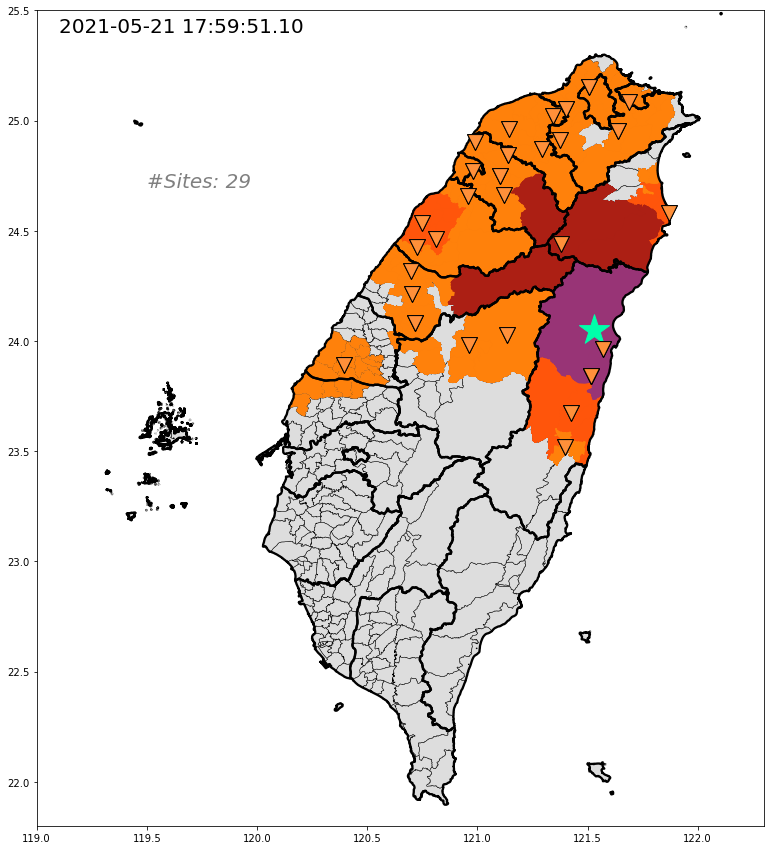

In [269]:
#plotting eq data
color_map = [
        '#C4FBE2',
        '#26FF0B',
        '#FFFE0B',
        '#FF810B',
        '#FF550B',
        '#AC1F14',
        '#A92700',
        '#983476',
        '#BB20D9'
]
cLevel = [1, 2, 3, 4, 5, 5.5, 6, 6.5, 7]
cmap, norm = matplotlib.colors.from_levels_and_colors(cLevel, color_map, extend="max")

#norm = matplotlib.colors.BoundaryNorm(cLevel,9)
#norm = matplotlib.colors.Normalize(vmin=1, vmax=7, clip=True)
#cm = matplotlib.colors.ListedColormap(color_map)
#cmap1 = LinearSegmentedColormap.from_list("my_colormap", color_map, N=9, gamma=1.0)


#map init
f, axes = plt.subplots(figsize=(15,15))
county.boundary.plot(ax=axes, color="black", edgecolor="black",linewidth=cbw, zorder=2)  #draw counties
l1 = town.plot(ax=axes, color="#dddddd", edgecolor="black", linewidth=tbw, zorder=1)     #draw towns
    
#set pic location
minx, miny, maxx, maxy = (origin_x, origin_y, origin_x + delta_x, origin_y + delta_y)
l1.set_xlim(minx, maxx)
l1.set_ylim(miny, maxy)
current_time = (datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00"))    
axes_time = axes.text(minx+0.1,maxy-0.1,(datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00")), size=t_size)
axes_site_count = axes.text(119.5, 24.7, "#Sites:"+str(len(trigger_site)), size=t_size, style='italic', c="gray")


#plotting eq_center
eq_center = pd.DataFrame({"Name":"eq_center", "Latitude":[Lat], "Longitude":[Lon]})
eq_center = gpd.GeoDataFrame(eq_center, geometry=gpd.points_from_xy(eq_center.Longitude, eq_center.Latitude))
eq_center.plot(ax=axes, color="#00ffaa", marker="*", markersize=1000, zorder=3)
op = 0 #temproary

p_radius, s_radius, current_time, trigger_site, trigger_cwb = gen_gap_frame(axes, current_time, site_times, site_geo, gap_list, frame_rate, axes.texts, p_radius, s_radius, trigger_site, trigger_cwb)

print("1",current_time)
for item in data: 
    
    date = item["Date"]
    time = item["Time"]
    Areas = item["Areas"]
    AreaDetail = []
    draw_area = gpd.GeoDataFrame()
    data_time = (datetime.strptime(date+" "+time, "%Y-%m-%d %H:%M:%S.%f"))
    #print("dt= ")

    #if data_time - current_time >= timedelta(seconds=frame_rate):
    while current_time <= data_time:
        #print(site_times)
        current_time += timedelta(seconds=frame_rate)
    print(current_time)
    current_time_str = current_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-4]
    
    #plotting key frame
    for Area in Areas:
        AreaDetail.append((Area["AreaCode"], Area["Source"], Area["PGA"], float(Area["Intensity"])))

    data = pd.DataFrame(AreaDetail, columns=["AreaCode", "Source", "PGA", "Intensity"])
    data = data.sort_values(by=["AreaCode", "PGA"])
    for i in range(len(data)):
        draw = town[town.TOWNCODE == data.loc[i, "AreaCode"]]
        draw = draw.assign(Intensity = data.loc[i, "Intensity"])
        draw_area = draw_area.append(draw)

    p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, ls="--", fill=False)
    axes.add_patch(p_circle)
    s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, fill=False)
    axes.add_patch(s_circle)
    draw_area.plot("Intensity", ax=axes, cmap=cmap, norm=norm)
    axes.texts[-2].set_text(current_time_str.replace("_",":"))
    axes.figure.savefig(current_time_str+".png")#str(current_time).replace(":", "_")+".png")
    
    p_circle.remove()
    s_circle.remove()
    op += 1

    p_radius, s_radius, current_time, trigger_site, trigger_cwb = gen_gap_frame(axes, current_time, site_times, site_geo, gap_list, frame_rate, axes.texts, p_radius, s_radius, trigger_site, trigger_cwb)
    print("2",current_time)

In [267]:
def gen_gap_list(data, cwb_origin_time):
    gap_list = []
    for ind, item in enumerate(data):
        current_datetime = round(datetime.strptime(item["Date"]+" "+item["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)
        next_ind = ind+1
        
        if ind == 0:
            cwb_gap = round(current_datetime - cwb_origin_time, 2)
            gap_list.append(cwb_gap)

        if next_ind == len(data):
            break
        next_datetime = round(datetime.strptime(data[next_ind]["Date"]+" "+data[next_ind]["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)

        gap = round(next_datetime - current_datetime, 2)
        gap_list.append(gap)

    return(gap_list)

gap_list = gen_gap_list(ld.load_data(mqtt_data), cwb_origin_time)
print(gap_list)

[0.68, 0.69, 4.33, 0.03, 0.71, 0.8, 0.87, 0.51, 4.55, 1.26, 0.13, 0.16, 0.05, 0.42, 0.47, 0.13, 0.72, 0.02, 0.24, 0.72, 0.34, 0.05, 0.21, 0.26, 0.45, 0.32, 1.06, 15.89]


In [268]:
def gen_gap_frame(ax, time, site_times, site_geo, gap_list, frame_rate, texts, p_radius, s_radius, site_count, cwb_count):
    #plotting gap frame
    plotting = False
    
    if len(gap_list) > 0:
        gaps = gap_list[0]
        loop_count = math.floor(gaps/frame_rate)

    else:
        return "gap_list len < 0"
    
    for x in range(int(loop_count)):
        time += timedelta(milliseconds=(frame_rate*1000))
        time_str = time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-4]
        p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, ls="--", fill=False)
        ax.add_patch(p_circle)
        s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, fill=False)
        ax.add_patch(s_circle)
        
        if site_times != []:
            site_time = datetime.strptime(site_times[0] ,"%Y-%m-%d %H:%M:%S.%f")
            #print("plot site")
            #print(site_time - current_time)
            if site_time - time <= timedelta(seconds=0.5) and plotting == False:
                print("plot1")
                plotting = True
                site_plot = site_geo.loc[site_df["Datetime"] == site_times[0], ["geometry"]]
                site_plot.plot(ax=axes, color="#3BFF3A", edgecolor="black", marker="v", markersize=250, zorder=3)
                #for ind,row in site_geo.iterrows():
                    #axes.text(s=row["Site_ID"],x=row["Site_Lon"], y=row["Site_Lat"]+0.08, style="italic", horizontalalignment='center', backgroundcolor="#FFFFFF", visible=True)
            if time >= site_time:
                print("plot2")
                site_id = site_df.loc[site_df["Datetime"] == site_times[0], ["Site_ID"]].values[0][0]
                if str(site_id) in site_count:
                    print("already in")
                else:
                    site_count.append(site_id)
                
                site_plot.plot(ax=axes, color="#FF903A", edgecolor="black", marker="v", markersize=250, zorder=4)
                site_times.pop(0)
                plotting = False

        p_radius += 0.005
        s_radius += 0.0025
        texts[-2].set_text(time_str.replace("_",":"))
        texts[-1].set_text("#Sites: "+str(len(site_count)))
        #print(texts)
        ax.plot()
        ax.figure.savefig(time_str+".png") #(time_str).replace(":", "_")+".png")
        
        p_circle.remove()
        s_circle.remove()
        print(time)
        
    gap_list.pop(0)
    return p_radius, s_radius, time, site_count, cwb_count

In [270]:
import imageio

impath = os.path.join(os.getcwd(), "2")
print(impath)
filenames = os.listdir(impath)
img = []
for filename in filenames:
    #print(filename)
    img.append(imageio.imread(os.path.join(impath, filename)))
print("張數:",len(img))
imageio.mimsave(os.path.join(impath, "test2.gif"), img)

C:\Hong_tmp\Git\eqreplay\2
張數: 361


In [ ]:
def plot_data_site():
    

In [3]:
site_data = ld.load_data("testsite.json")
print(site_data)

{'Date': '2021-03-04', 'Time': '22:25:05.703', 'Sites': [{'Site_Name': '台北市-桃源國小', 'Site_ID': 'S00110', 'Site_Lat': 25.154, 'Site_Lon': 121.507, 'Site_Level': '4', 'PGAx': 255.5}, {'Site_Name': '台中市-文武國小', 'Site_ID': 'S00078', 'Site_Lat': 24.38, 'Site_Lon': 120.638, 'Site_Level': '4', 'PGAx': 255.5}, {'Site_Name': '台南市-德高國小', 'Site_ID': 'S00020', 'Site_Lat': 23.2172, 'Site_Lon': 120.3651, 'Site_Level': '4', 'PGAx': 255.5}, {'Site_Name': '台北市-嘉誠國小', 'Site_ID': 'S00061', 'Site_Lat': 22.7486, 'Site_Lon': 120.3801, 'Site_Level': '4', 'PGAx': 255.5}]}
